## Autoencoders: Architecture Overview

An autoencoder is a type of neural network designed to learn efficient representations of data, typically for unsupervised tasks like dimensionality reduction, feature learning, or data denoising.

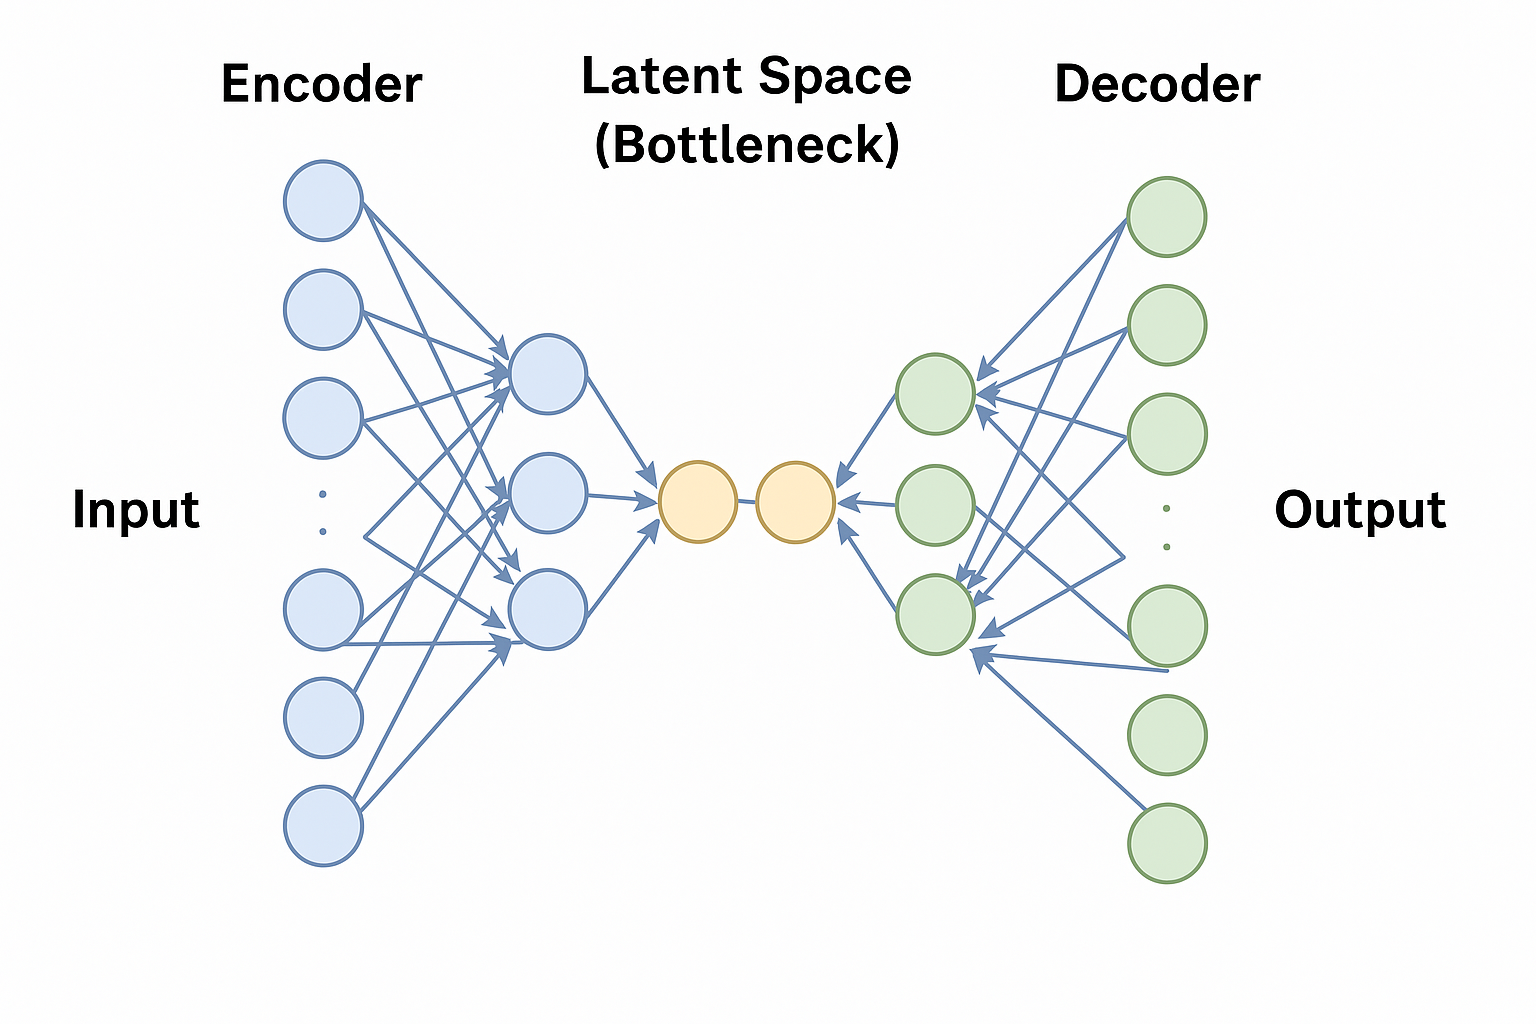



An autoencoder consists of two main parts:

**1. Encoder:**
The encoder compresses the input data into a lower-dimensional representation called the latent space or bottleneck. This part gradually reduces the input’s dimensionality through one or more hidden layers.

**2. Decoder:**
The decoder reconstructs the original data from the compressed latent representation. Its goal is to learn how to map the encoded features back to the original input as closely as possible.

The overall structure is symmetric:

* The encoder reduces dimensionality.
* The decoder mirrors this process to expand back to the original dimension.

The key idea is that the network is forced to learn the most important features of the data because it must compress and then reconstruct the input with minimal information loss.

Autoencoders are trained using unsupervised learning because they do not require labeled data. The training objective is to minimize the reconstruction loss — typically measured by the difference between the input and the output (e.g., mean squared error).

## Narration: Understanding the Autoencoder Architecture

An autoencoder is one of the fundamental neural network structures used for unsupervised learning tasks. Unlike supervised learning, where we train models with input-output label pairs, an autoencoder learns directly from the raw input data by trying to reproduce it at the output. This forces the model to discover useful compressed representations.

The structure of an autoencoder is built around two main components: the encoder and the decoder.

**Encoder:**
The encoder acts like a funnel that takes the high-dimensional input data and projects it into a lower-dimensional latent space. This is done through a series of layers that gradually reduce the dimensionality of the data. The intuition is that the encoder must find the essential patterns or features in the input that best describe it in a compressed form. The point of maximum compression is often called the **bottleneck**. The smaller the bottleneck, the more the network is forced to learn meaningful patterns and ignore noise or redundancy.

**Latent Space (Bottleneck):**
At the center of the network is the latent space, also called the bottleneck or code. This is the heart of the autoencoder’s capability. If the bottleneck is too large, the network can simply memorize the input and learn an identity mapping, which is not useful. A well-chosen bottleneck size forces the model to learn efficient, compressed representations that still retain enough information to reconstruct the original input.

**Decoder:**
The decoder does the reverse of the encoder. Its job is to expand the compressed data back to the original input dimension. The decoder tries to rebuild the original input as accurately as possible using only the compressed information provided by the encoder. The reconstruction must be close enough that the overall error is minimal.

**Symmetry:**
Autoencoders are usually symmetric in structure: the decoder mirrors the encoder’s architecture. If the encoder has layers with sizes 784 → 128 → 64 → 32, the decoder will typically expand back 32 → 64 → 128 → 784. This symmetry helps ensure that the reconstruction matches the input shape and data type.


Autoencoders are a practical example of how neural networks can be used for unsupervised representation learning — a critical building block for many advanced applications, including generative models and deep clustering.


## **Step-by-Step Autoencoder in Keras**

In [1]:
# Step 1: Import required libraries
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers


**Narration:**
First, we import the essential libraries.
We use NumPy for basic data handling and TensorFlow Keras for building the autoencoder model.
The `layers` module from Keras provides building blocks like Dense layers for our network.

In [2]:
# Step 2: Load the MNIST dataset as an example
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

**Narration:**
Next, we load the MNIST dataset, which contains 28x28 grayscale images of handwritten digits.
Since an autoencoder is unsupervised, we do not need the labels, so we use an underscore `_` to ignore them.


In [3]:
# Step 3: Normalize and flatten the data
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = x_train.reshape((len(x_train), 28 * 28))
x_test = x_test.reshape((len(x_test), 28 * 28))


**Narration:**
We then normalize the pixel values to the range \[0, 1] by dividing by 255.
This helps the network train faster and more effectively.
After normalization, we flatten each 28x28 image into a single 784-dimensional vector because our dense layers expect 1D input.

In [4]:
# Step 4: Define the size of our encoded representation
encoding_dim = 32  # Size of the bottleneck layer

**Narration:**
Here, we set the size of the latent space or bottleneck.
We choose 32 dimensions, which means the network will compress the 784 input values into just 32 values at the center.


In [5]:
# Step 5: Build the encoder
input_img = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)


**Narration:**
Now we build the encoder part of the autoencoder.

* `input_img` defines the input layer, which accepts vectors of size 784.
* The first Dense layer reduces the size to 128 neurons with ReLU activation.
* The next layer reduces it further to 64 neurons.
* Finally, we reach the bottleneck layer with 32 neurons, our compressed latent representation.

In [6]:
# Step 6: Build the decoder
decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)


**Narration:**
Next, we build the decoder, which mirrors the encoder’s structure in reverse.

* The decoder expands the bottleneck output back to 64 neurons.
* Then it expands further to 128 neurons.
* Finally, it reconstructs the original 784-length vector.
  The output layer uses a sigmoid activation because pixel values are in the range \[0, 1].


In [7]:
# Step 7: Combine encoder and decoder into an autoencoder model
autoencoder = keras.Model(input_img, decoded)

**Narration:**
We connect the encoder and decoder into one complete model.
The input goes into the encoder, gets compressed, and then the decoder reconstructs it.
This defines our full autoencoder network.


In [8]:
# Step 8: Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

**Narration:**
We compile the autoencoder by setting the optimizer and loss function.
We use the Adam optimizer for efficient training and binary cross-entropy loss since we treat pixel values as probabilities between 0 and 1.


In [9]:
# Step 9: Train the model
autoencoder.fit(x_train, x_train,
                epochs=20,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.2440 - val_loss: 0.1674
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1506 - val_loss: 0.1386
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1330 - val_loss: 0.1257
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1232 - val_loss: 0.1186
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1171 - val_loss: 0.1132
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1124 - val_loss: 0.1088
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1082 - val_loss: 0.1050
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1050 - val_loss: 0.1023
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1026 - val_loss: 0.1007
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1008 - val_loss: 0.0992
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0994 - val_loss: 0.0978
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step

**Narration:**
Finally, we train the autoencoder.
Notice that both the input and output are the same (`x_train`).
This is because the autoencoder learns to reconstruct its own input.
We run for 20 epochs, use a batch size of 256, shuffle the data for each epoch, and validate using the test data.


In [10]:
# Step 10: Use the trained autoencoder to encode and decode images
encoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


**Narration:**
After training, we can use the autoencoder to compress and reconstruct images.
This line predicts the reconstructed images for the test set so we can see how well the model learned to recreate the inputs.

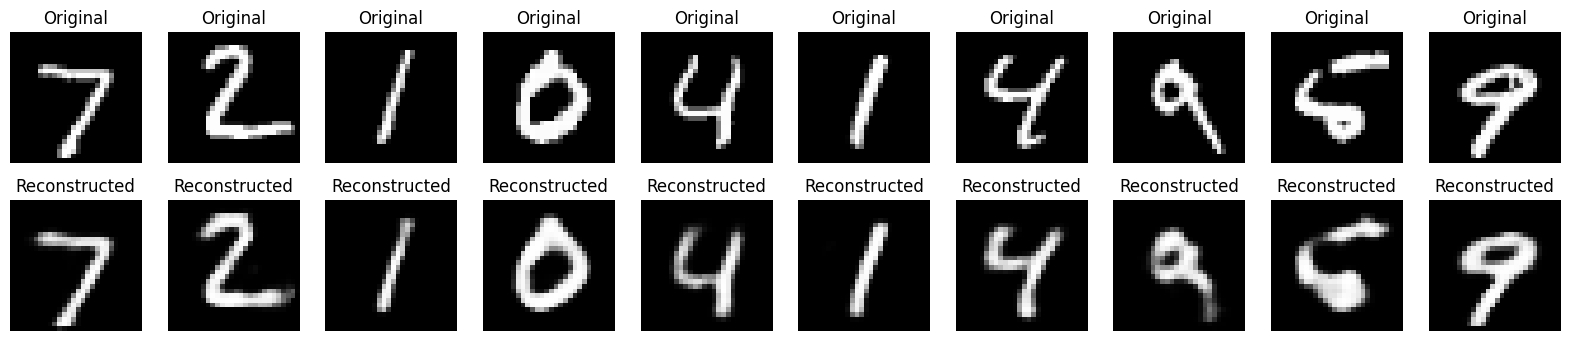

In [11]:
import matplotlib.pyplot as plt

# Number of images to display
n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()


## **Narration**

In this final step, we visualize how well our trained autoencoder performs by comparing some original images with their reconstructions.

We display a few images from the test set:

* The **first row** shows the **original input images**.
* The **second row** shows the **images reconstructed** by the autoencoder.

We reshape each vector of size 784 back into its original 28×28 image form for display.

By looking at these side by side, we can observe whether the autoencoder has learned to capture the key features of each digit. Good reconstructions mean the network has successfully learned an efficient compressed representation of the data in the latent space.
